In [2]:
from datetime import datetime
from pathlib import Path
from pyspark.sql import SparkSession, functions as F
from pyspark.sql.types import *
import folium
import geopandas as gpd
import matplotlib.pyplot as plt
import pandas as pd
from shapely import wkt

SITE_DATA_DIR = Path("../data/processed/traffic_site/top_100_sites.csv")
VOLUME_DATA_DIR = "../data/processed/traffic_volume"

In [3]:
# ---------------------------------------------------------------------------------------------------------------
# PLOT TOP 100 CLOSEST TRAFFIC SITES
# ---------------------------------------------------------------------------------------------------------------
site_df = pd.read_csv(SITE_DATA_DIR)
site_df["geometry"] = site_df["geometry"].apply(wkt.loads)
site_gdf = gpd.GeoDataFrame(site_df, geometry="geometry", crs="EPSG:4326")

# Create map
centre = [site_gdf.geometry.y.mean(), site_gdf.geometry.x.mean()]
map = folium.Map(location=centre, zoom_start=12)

# Plot traffic sites
for row in site_gdf.itertuples():
    folium.CircleMarker(location=[row.geometry.y, row.geometry.x],
                        radius=4,
                        fill=True,
                        popup=f"Site: {row.site_id}, Name: {row.site_name}").add_to(map)

map

Using Spark's default log4j profile: org/apache/spark/log4j2-defaults.properties
26/01/14 06:10:44 WARN Utils: Your hostname, MSI, resolves to a loopback address: 127.0.1.1; using 10.255.255.254 instead (on interface lo)
26/01/14 06:10:44 WARN Utils: Set SPARK_LOCAL_IP if you need to bind to another address
Using Spark's default log4j profile: org/apache/spark/log4j2-defaults.properties
Setting default log level to "WARN".
To adjust logging level use sc.setLogLevel(newLevel). For SparkR, use setLogLevel(newLevel).
26/01/14 06:10:45 WARN NativeCodeLoader: Unable to load native-hadoop library for your platform... using builtin-java classes where applicable


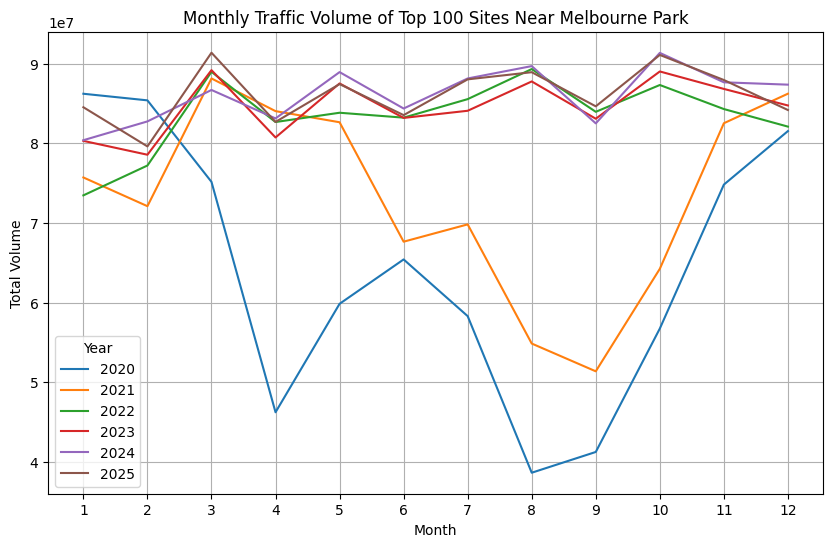

In [4]:
# ---------------------------------------------------------------------------------------------------------------
# VISUALISE MONTHLY TOTAL TRAFFIC VOLUME
# ---------------------------------------------------------------------------------------------------------------
spark = SparkSession.builder.getOrCreate()

df = spark.read.parquet(VOLUME_DATA_DIR)

# Change schema 
new_schema = StructType([StructField("date", DateType()),
                         StructField("hour", IntegerType()),
                         StructField("site_id", IntegerType()),
                         StructField("volume", IntegerType())])
df = df.to(new_schema)

# Sum volume by day
total_monthly_volume = df.select("date", "volume") \
                         .groupBy("date") \
                         .agg(F.sum("volume").alias("total_monthly_volume")) \
                         .sort("date")

# Convert Sparks dataframe to Pandas
pdf = total_monthly_volume.toPandas()
pdf["date"] = pd.to_datetime(pdf["date"])
pdf["year"] = pdf["date"].dt.year
pdf["month"] = pdf["date"].dt.month

# Sum volume by month
pdf = pdf[["year", "month", "total_monthly_volume"]].groupby(["year", "month"], as_index=False).sum()
pdf.head()

plt.figure(figsize=(10, 6))

for year in range(2020, 2026):

    year_df = pdf[pdf["year"] == year]

    plt.plot(year_df["month"], 
             year_df["total_monthly_volume"],
             label=str(year))
    
plt.xlabel("Month")
plt.ylabel("Total Volume")
plt.title("Monthly Traffic Volume of Top 100 Sites Near Melbourne Park")
plt.xticks(range(1,13))
plt.legend(title="Year")
plt.grid(True)
plt.show()